# **Experiments #3 — POA with Randomize Initialization Representative Solution then Optimized**

### **Knowledge objectives:**
- Prove which timetable process order is sequentially better
    - Teachers → rooms → timeslots
    - Rooms → teachers → timeslots
    - Timeslots → rooms → teachers
- Prove that scheduling based on teacher laboratory expertise is more effective
- Prove the percentage of teachers not teaching linearly with their lab expertise
- Prove that computational environment has different impact on solution generation

---

# **Data Setup**

## *Import Used Library*

In [1]:
# ──────────────────────────────────────────────────────────────
# Cell 1 ▸ Import Used Libraries
# ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import random
import time
import warnings
from collections import defaultdict
from itertools import combinations
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")

# Reproducibility seed (overridden in Experiment #3 runs)
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
random.seed(GLOBAL_SEED)

print("Libraries loaded successfully.")
print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")


Libraries loaded successfully.
NumPy  : 1.26.4
Pandas : 2.1.4


## *Dataset Understanding*

Showing attributes of courses, teachers, laboratorium, rooms, and timeslots

In [8]:
# ──────────────────────────────────────────────────────────────
# Cell 2 ▸ Dataset Understanding
# ──────────────────────────────────────────────────────────────

# ── Load raw data ─────────────────────────────────────────────
df_courses_raw   = pd.read_csv("/home/emery/Documents/Scheduling_Puma_Optimizer/app/assets/data/mk_dsi.csv")
df_lab_expertise = pd.read_csv("/home/emery/Documents/Scheduling_Puma_Optimizer/app/assets/data/teacher_lab_expertise.csv")
df_rooms_all     = pd.read_csv("/home/emery/Documents/Scheduling_Puma_Optimizer/app/assets/data/rooms.csv")
df_prac_rooms    = pd.read_csv("/home/emery/Documents/Scheduling_Puma_Optimizer/app/assets/data/practicum_rooms.csv")
df_days_raw      = pd.read_csv("/home/emery/Documents/Scheduling_Puma_Optimizer/app/assets/data/days.csv")

# ── Courses overview ──────────────────────────────────────────
print("=" * 60)
print("COURSES DATASET  (mk_dsi.csv)")
print("=" * 60)
print(df_courses_raw.head(6).to_string(index=False))
print(f"\nShape            : {df_courses_raw.shape}")
print(f"Unique course_id : {df_courses_raw['course_id'].nunique()}")
print(f"Unique prodi     : {df_courses_raw['prodi'].nunique()}")
print(f"Unique teachers  : {df_courses_raw['teacher_id'].nunique()}")
print("\nSemester dist.  :", df_courses_raw["course_genap_ganjil"].value_counts().to_dict())
print("Course type     :", df_courses_raw["course_type"].value_counts().to_dict())
print("Has practicum   :", df_courses_raw["course_has_practicum"].value_counts().to_dict())
print("SKS range       :", df_courses_raw["sks"].min(), "–", df_courses_raw["sks"].max())

# ── Teacher lab expertise overview ───────────────────────────
print("\n" + "=" * 60)
print("TEACHER LAB EXPERTISE  (teacher_lab_expertise.csv)")
print("=" * 60)
print(df_lab_expertise.head(10).to_string(index=False))
print(f"\nTotal teachers with lab : {len(df_lab_expertise)}")
print("Lab distribution       :", df_lab_expertise["lab"].value_counts().to_dict())

# ── Rooms overview ────────────────────────────────────────────
print("\n" + "=" * 60)
print("THEORY ROOMS  (rooms.csv)")
print("=" * 60)
print(df_rooms_all.to_string(index=False))
print(f"\nTotal theory rooms  : {len(df_rooms_all)}")
print("Floor distribution  :", df_rooms_all["floor"].value_counts().sort_index().to_dict())

print("\n" + "=" * 60)
print("PRACTICUM ROOMS  (practicum_rooms.csv)")
print("=" * 60)
print(df_prac_rooms.to_string(index=False))
print(f"\nTotal practicum rooms : {len(df_prac_rooms)}")

# ── Days & timeslots overview ────────────────────────────────
DAYS        = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
SLOTS_PER_DAY = 13      # 13 slots × 50 min = 650 min per day
SLOT_DURATION = 50      # minutes per slot
START_HOUR    = 7       # first slot starts at 07:00

slot_times = [
    f"{(START_HOUR + i * SLOT_DURATION // 60):02d}:{(i * SLOT_DURATION % 60):02d}"
    for i in range(SLOTS_PER_DAY)
]

print("\n" + "=" * 60)
print("DAYS & TIMESLOTS")
print("=" * 60)
print(f"Days            : {DAYS}")
print(f"Slots / day     : {SLOTS_PER_DAY}  (@{SLOT_DURATION} min each)")
print(f"Slot start times: {slot_times}")
print(f"Total slot×room : {SLOTS_PER_DAY} × {len(df_days_raw)} days × n_rooms")


COURSES DATASET  (mk_dsi.csv)
course_id                                 course_name                          prodi  sks course_genap_ganjil course_type course_has_practicum  teacher_priority teacher_position teacher_id
 CSD60704                           Desain Basis Data            Teknologi Informasi    2               Genap       Wajib                Tidak                 1         Pengampu          1
 CIT62022 Implementasi dan Pengujian Sistem Informasi            Teknologi Informasi    2               Genap       Wajib                Tidak                 1         Pengampu          1
 CIT60048                       Information Retrieval            Teknologi Informasi    2        Ganjil/Genap     Pilihan                Tidak                 1         Pengampu          1
 CSD60714            Jaminan Kualitas Perangkat Lunak Pendidikan Teknologi Informasi    3               Genap       Wajib                Tidak                 1         Pengampu          1
 CSD60714            Jami

## *Splitting Course Ganjil — Genap*

In [9]:
# ──────────────────────────────────────────────────────────────
# Cell 3 ▸ Splitting Courses: Ganjil vs Genap
# ──────────────────────────────────────────────────────────────

# Genap semester includes "Genap" and "Ganjil/Genap" (offered every semester)
GENAP_VALUES = ["Genap", "Ganjil/Genap"]

df_genap  = df_courses_raw[df_courses_raw["course_genap_ganjil"].isin(GENAP_VALUES)].copy()
df_ganjil = df_courses_raw[df_courses_raw["course_genap_ganjil"] == "Ganjil"].copy()

print("=" * 60)
print("SEMESTER SPLIT")
print("=" * 60)
print(f"Total rows (raw)   : {len(df_courses_raw)}")
print(f"Genap rows         : {len(df_genap)}  "
      f"({len(df_genap)/len(df_courses_raw)*100:.1f}%)")
print(f"Ganjil-only rows   : {len(df_ganjil)}  "
      f"({len(df_ganjil)/len(df_courses_raw)*100:.1f}%)")

# Unique course offerings (course_id × prodi) per semester
genap_offerings  = df_genap.drop_duplicates(subset=["course_id","prodi"])[["course_id","course_name","prodi","sks","course_type","course_has_practicum"]]
ganjil_offerings = df_ganjil.drop_duplicates(subset=["course_id","prodi"])[["course_id","course_name","prodi","sks","course_type","course_has_practicum"]]

print(f"\nUnique GENAP offerings (course×prodi)  : {len(genap_offerings)}")
print(f"Unique GANJIL offerings (course×prodi) : {len(ganjil_offerings)}")

print("\nSample GENAP offerings:")
print(genap_offerings.head(10).to_string(index=False))

# Working dataset = Genap
df_working = df_genap.copy()
print(f"\n>>> Working dataset set to GENAP: {len(df_working)} rows, "
      f"{len(genap_offerings)} unique offerings")


SEMESTER SPLIT
Total rows (raw)   : 846
Genap rows         : 602  (71.2%)
Ganjil-only rows   : 244  (28.8%)

Unique GENAP offerings (course×prodi)  : 96
Unique GANJIL offerings (course×prodi) : 75

Sample GENAP offerings:
course_id                                 course_name                          prodi  sks course_type course_has_practicum
 CSD60704                           Desain Basis Data            Teknologi Informasi    2       Wajib                Tidak
 CIT62022 Implementasi dan Pengujian Sistem Informasi            Teknologi Informasi    2       Wajib                Tidak
 CIT60048                       Information Retrieval            Teknologi Informasi    2     Pilihan                Tidak
 CSD60714            Jaminan Kualitas Perangkat Lunak Pendidikan Teknologi Informasi    3       Wajib                Tidak
 CSD60714            Jaminan Kualitas Perangkat Lunak            Teknologi Informasi    3     Pilihan                Tidak
 COM60024                          Pemro

## *Splitting Selected Courses by Theory and Practicum*

In [10]:
# ──────────────────────────────────────────────────────────────
# Cell 4 ▸ Splitting Courses: Theory vs Practicum
# ──────────────────────────────────────────────────────────────

# Build unique offering table from genap working set
df_offerings = (
    df_working
    .drop_duplicates(subset=["course_id", "prodi"])
    [["course_id", "course_name", "prodi", "sks",
      "course_type", "course_has_practicum"]]
    .reset_index(drop=True)
)

df_theory    = df_offerings[df_offerings["course_has_practicum"] == "Tidak"].copy()
df_practicum = df_offerings[df_offerings["course_has_practicum"] == "Ya"].copy()

print("=" * 60)
print("THEORY vs PRACTICUM SPLIT  (Genap offerings)")
print("=" * 60)
print(f"Total unique offerings : {len(df_offerings)}")
print(f"  ▸ Theory-only        : {len(df_theory)}")
print(f"  ▸ Has practicum      : {len(df_practicum)}")

print("\nTheory courses (sample):")
print(df_theory[["course_id","course_name","prodi","sks","course_type"]].head(8).to_string(index=False))

print("\nCourses with practicum sessions:")
print(df_practicum[["course_id","course_name","prodi","sks","course_type"]].to_string(index=False))

# Build the master list of SCHEDULING UNITS
# Each unit = one class session that must be assigned {teacher, room, day, timeslot}
#   - Every offering → 1 theory unit
#   - If has_practicum == "Ya" → additional 1 practicum unit
scheduling_units = []

for _, row in df_offerings.iterrows():
    # Theory unit
    scheduling_units.append({
        "unit_id"         : f"{row['course_id']}__{row['prodi']}__TH",
        "course_id"       : row["course_id"],
        "course_name"     : row["course_name"],
        "prodi"           : row["prodi"],
        "sks"             : row["sks"],
        "course_type"     : row["course_type"],
        "session_type"    : "Theory",
    })
    # Practicum unit (if applicable)
    if row["course_has_practicum"] == "Ya":
        scheduling_units.append({
            "unit_id"     : f"{row['course_id']}__{row['prodi']}__PR",
            "course_id"   : row["course_id"],
            "course_name" : row["course_name"],
            "prodi"       : row["prodi"],
            "sks"         : row["sks"],
            "course_type" : row["course_type"],
            "session_type": "Practicum",
        })

df_units = pd.DataFrame(scheduling_units)
n_units  = len(df_units)

print(f"\nTotal scheduling units : {n_units}")
print(f"  ▸ Theory sessions   : {(df_units['session_type']=='Theory').sum()}")
print(f"  ▸ Practicum sessions: {(df_units['session_type']=='Practicum').sum()}")
print("\nScheduling units (sample):")
print(df_units.head(12).to_string(index=False))


THEORY vs PRACTICUM SPLIT  (Genap offerings)
Total unique offerings : 96
  ▸ Theory-only        : 80
  ▸ Has practicum      : 16

Theory courses (sample):
course_id                                 course_name                          prodi  sks course_type
 CSD60704                           Desain Basis Data            Teknologi Informasi    2       Wajib
 CIT62022 Implementasi dan Pengujian Sistem Informasi            Teknologi Informasi    2       Wajib
 CIT60048                       Information Retrieval            Teknologi Informasi    2     Pilihan
 CSD60714            Jaminan Kualitas Perangkat Lunak Pendidikan Teknologi Informasi    3       Wajib
 CSD60714            Jaminan Kualitas Perangkat Lunak            Teknologi Informasi    3     Pilihan
 CIS62106                             Pemrograman Web               Sistem Informasi    4       Wajib
 CIS60103                      Pemrograman Web Lanjut               Sistem Informasi    3     Pilihan
 CSD60708                    

## *Generated Course Time based on SKS*

In [11]:
# ──────────────────────────────────────────────────────────────
# Cell 5 ▸ Generated Course Time based on SKS
# ──────────────────────────────────────────────────────────────
#   ▸ SKS <= 3  → 100 min session  → occupies 2 consecutive slots
#   ▸ SKS >= 4  → 150 min session  → occupies 3 consecutive slots

def sks_to_slots(sks: int) -> int:
    """Map SKS to number of 50-min slots consumed per session."""
    return 2 if sks <= 3 else 3

def sks_to_minutes(sks: int) -> int:
    return sks_to_slots(sks) * SLOT_DURATION   # 100 or 150 min

df_units["slots_needed"]   = df_units["sks"].apply(sks_to_slots)
df_units["duration_mins"]  = df_units["sks"].apply(sks_to_minutes)

# Maximum valid start slot (so the session fits within the day)
df_units["max_start_slot"] = SLOTS_PER_DAY - df_units["slots_needed"]

print("=" * 60)
print("COURSE TIME ALLOCATION (by SKS)")
print("=" * 60)
summary = (
    df_units.groupby("slots_needed")
    .agg(count=("unit_id","count"), sample_sks=("sks","unique"))
    .reset_index()
    .rename(columns={"slots_needed":"slots (50 min each)"})
)
for _, r in summary.iterrows():
    mins = int(r["slots (50 min each)"]) * SLOT_DURATION
    print(f"  {int(r['slots (50 min each)'])} slots = {mins} min  |  "
          f"{int(r['count'])} units  |  SKS values: {r['sample_sks']}")

print("\nSKS → slot mapping detail:")
for sks_val in sorted(df_units["sks"].unique()):
    slots = sks_to_slots(sks_val)
    print(f"  SKS {sks_val:2d}  → {slots} slots  "
          f"({slots * SLOT_DURATION} min)  "
          f"max_start_slot = {SLOTS_PER_DAY - slots}")

print("\nScheduling units with time info (sample):")
print(df_units[["unit_id","sks","slots_needed","duration_mins","max_start_slot"]].head(10).to_string(index=False))


COURSE TIME ALLOCATION (by SKS)
  2 slots = 100 min  |  101 units  |  SKS values: [2 3]
  3 slots = 150 min  |  11 units  |  SKS values: [5 4]

SKS → slot mapping detail:
  SKS  2  → 2 slots  (100 min)  max_start_slot = 11
  SKS  3  → 2 slots  (100 min)  max_start_slot = 11
  SKS  4  → 3 slots  (150 min)  max_start_slot = 10
  SKS  5  → 3 slots  (150 min)  max_start_slot = 10

Scheduling units with time info (sample):
                                     unit_id  sks  slots_needed  duration_mins  max_start_slot
           CSD60704__Teknologi Informasi__TH    2             2            100              11
           CIT62022__Teknologi Informasi__TH    2             2            100              11
           CIT60048__Teknologi Informasi__TH    2             2            100              11
CSD60714__Pendidikan Teknologi Informasi__TH    3             2            100              11
           CSD60714__Teknologi Informasi__TH    3             2            100              11
        

## *Splitting Teachers based on Courses Coordinator or Not*

In [12]:
# ──────────────────────────────────────────────────────────────
# Cell 6 ▸ Splitting Teachers: Coordinator vs Non-Coordinator
# ──────────────────────────────────────────────────────────────

# Normalise teacher_position field (strip whitespace, unify casing)
df_working["teacher_position"] = df_working["teacher_position"].str.strip()

# Classify coordinator vs non-coordinator
def is_coordinator(position: str) -> bool:
    return "Koordinator" in str(position)

df_working["is_coordinator"] = df_working["teacher_position"].apply(is_coordinator)

# Merge lab expertise
df_lab_expertise["lecturer_id"] = df_lab_expertise["lecturer_id"].astype(str)
df_working["teacher_id"]        = df_working["teacher_id"].astype(str)

df_working = df_working.merge(
    df_lab_expertise.rename(columns={"lecturer_id":"teacher_id", "lab":"teacher_lab"}),
    on="teacher_id", how="left"
)

# ── Build per-unit eligible teacher index ─────────────────────
# eligible_teachers[unit_id] = list of teacher_id strings eligible for that unit
eligible_teachers = {}

for _, unit in df_units.iterrows():
    uid   = unit["unit_id"]
    cid   = unit["course_id"]
    prodi = unit["prodi"]
    mask  = (
        (df_working["course_id"] == cid) &
        (df_working["prodi"]     == prodi) &
        (df_working["teacher_id"] != "0")   # exclude placeholder zeros
    )
    teachers_for_unit = df_working.loc[mask, "teacher_id"].dropna().unique().tolist()
    # Filter out TBA teachers from hard-constraint perspective but keep for scheduling
    eligible_teachers[uid] = teachers_for_unit if teachers_for_unit else ["TBA"]

# ── Teacher priority lookup ───────────────────────────────────
teacher_priority = {}    # (teacher_id, unit_id) → priority int
for _, row in df_working.iterrows():
    cid   = row["course_id"]
    prodi = row["prodi"]
    t_id  = str(row["teacher_id"])
    # Map to both theory and practicum unit IDs for this course
    for suffix in ["TH", "PR"]:
        uid = f"{cid}__{prodi}__{suffix}"
        try:
            teacher_priority[(t_id, uid)] = int(row["teacher_priority"])
        except (ValueError, TypeError):
            teacher_priority[(t_id, uid)] = 2

# ── Teacher lab expertise dict ────────────────────────────────
teacher_lab = {}      # teacher_id (str) → lab name
for _, row in df_lab_expertise.iterrows():
    teacher_lab[str(row["lecturer_id"])] = row["lab"]

# ── Coordinator sets ─────────────────────────────────────────
coordinator_teachers    = set(
    df_working[df_working["is_coordinator"] == True]["teacher_id"].unique()
)
non_coordinator_teachers = set(
    df_working[df_working["is_coordinator"] == False]["teacher_id"].unique()
) - coordinator_teachers

print("=" * 60)
print("TEACHER CLASSIFICATION")
print("=" * 60)
print(f"Total unique teachers in working set  : {df_working['teacher_id'].nunique()}")
print(f"  ▸ Coordinators                      : {len(coordinator_teachers)}")
print(f"  ▸ Non-coordinators (Pengampu only)  : {len(non_coordinator_teachers)}")
print(f"  ▸ Teachers with lab expertise mapped: {len(teacher_lab)}")

# Lab alignment analysis
all_teachers_working = df_working["teacher_id"].unique()
no_lab_info = [t for t in all_teachers_working if t not in teacher_lab and not str(t).startswith("TBA")]
print(f"  ▸ Teachers without lab record       : {len(no_lab_info)}")

print("\nEligible teachers per unit (sample):")
for uid, teachers in list(eligible_teachers.items())[:6]:
    print(f"  {uid[:60]:60s}  → {len(teachers)} eligible teachers")

print("\nCoordinator sample (first 10):", list(coordinator_teachers)[:10])


TEACHER CLASSIFICATION
Total unique teachers in working set  : 111
  ▸ Coordinators                      : 19
  ▸ Non-coordinators (Pengampu only)  : 92
  ▸ Teachers with lab expertise mapped: 109
  ▸ Teachers without lab record       : 0

Eligible teachers per unit (sample):
  CSD60704__Teknologi Informasi__TH                             → 12 eligible teachers
  CIT62022__Teknologi Informasi__TH                             → 9 eligible teachers
  CIT60048__Teknologi Informasi__TH                             → 8 eligible teachers
  CSD60714__Pendidikan Teknologi Informasi__TH                  → 5 eligible teachers
  CSD60714__Teknologi Informasi__TH                             → 5 eligible teachers
  COM60024__Sistem Informasi__TH                                → 20 eligible teachers

Coordinator sample (first 10): ['98', '47', '92', '22', '13', '72', '20', '11', 'TBA_17', '53']


## *Splitting Rooms with Practicum and Theory*

In [13]:
# ──────────────────────────────────────────────────────────────
# Cell 7 ▸ Splitting Rooms: Theory vs Practicum
# ──────────────────────────────────────────────────────────────

# Theory rooms = all rooms
theory_rooms    = df_rooms_all["room_id"].tolist()
practicum_rooms = df_prac_rooms["room_id"].tolist()

# Room floor lookup (for soft constraint: movement penalty)
room_floor = {
    row["room_id"]: row["floor"]
    for _, row in df_rooms_all.iterrows()
}
for _, row in df_prac_rooms.iterrows():
    room_floor[row["room_id"]] = row["floor"]   # practicum rooms have same floor

# Index maps (list index → room_id and reverse)
theory_room_idx    = {r: i for i, r in enumerate(theory_rooms)}
practicum_room_idx = {r: i for i, r in enumerate(practicum_rooms)}

print("=" * 60)
print("ROOM SPLIT")
print("=" * 60)
print(f"Theory rooms      : {len(theory_rooms)}")
print(f"Practicum rooms   : {len(practicum_rooms)}")
print(f"\nTheory rooms by floor:")
for floor, grp in df_rooms_all.groupby("floor"):
    print(f"  Floor {floor}: {grp['room_id'].tolist()}")

print(f"\nPracticum rooms   : {practicum_rooms}")

# Assign room pool per unit
def get_room_pool(session_type: str) -> list:
    return practicum_rooms if session_type == "Practicum" else theory_rooms

df_units["room_pool"]      = df_units["session_type"].apply(get_room_pool)
df_units["n_rooms_avail"]  = df_units["room_pool"].apply(len)

print("\nRoom pool per session type:")
print(df_units.groupby("session_type")["n_rooms_avail"].first().to_dict())


ROOM SPLIT
Theory rooms      : 44
Practicum rooms   : 12

Theory rooms by floor:
  Floor 1: ['G1.2', 'G1.3', 'G1.4', 'G1.5', 'G1.6']
  Floor 2: ['F2.1', 'F2.2', 'F2.4', 'F2.5', 'F2.6', 'F2.8', 'F2.9']
  Floor 3: ['F3.1', 'F3.10', 'F3.11', 'F3.12', 'F3.13', 'F3.14', 'F3.15', 'F3.16', 'F3.17', 'F3.18', 'F3.2', 'F3.3', 'F3.4', 'F3.5a', 'F3.5b', 'F3.6', 'F3.7a', 'F3.7b', 'F3.8', 'F3.9']
  Floor 4: ['F4.10', 'F4.11', 'F4.12', 'F4.13', 'F4.14', 'F4.2', 'F4.3', 'F4.4', 'F4.5', 'F4.6', 'F4.7', 'F4.9']

Practicum rooms   : ['G1.2', 'G1.3', 'G1.4', 'G1.5', 'G1.6', 'F2.1', 'F2.2', 'F2.4', 'F2.5', 'F2.6', 'F2.8', 'F2.9']

Room pool per session type:
{'Practicum': 12, 'Theory': 44}


## *Generated Timeslots per Rooms*

- Has 13 slots per day @slot 50 mins

In [14]:
# ──────────────────────────────────────────────────────────────
# Cell 8 ▸ Generated Timeslots per Room
#   13 slots/day  ×  5 days  ×  n_rooms
# ──────────────────────────────────────────────────────────────

N_DAYS   = len(DAYS)        # 5
N_SLOTS  = SLOTS_PER_DAY   # 13

# ── Full timeslot grid ────────────────────────────────────────
timeslot_records = []
for room in theory_rooms + [r for r in practicum_rooms if r not in theory_rooms]:
    rtype = "Practicum" if room in practicum_rooms else "Theory"
    for d_idx, day in enumerate(DAYS):
        for s_idx in range(N_SLOTS):
            start_min  = s_idx * SLOT_DURATION
            start_hhmm = f"{START_HOUR + start_min // 60:02d}:{start_min % 60:02d}"
            timeslot_records.append({
                "room_id"     : room,
                "room_type"   : rtype,
                "day_idx"     : d_idx,
                "day"         : day,
                "slot_idx"    : s_idx,
                "start_time"  : start_hhmm,
                "end_time_2s" : f"{START_HOUR + (start_min+100)//60:02d}:{(start_min+100)%60:02d}",
                "end_time_3s" : f"{START_HOUR + (start_min+150)//60:02d}:{(start_min+150)%60:02d}",
            })

df_timeslots = pd.DataFrame(timeslot_records)

total_slots = N_DAYS * N_SLOTS
print("=" * 60)
print("TIMESLOT GRID")
print("=" * 60)
print(f"Days                       : {N_DAYS}")
print(f"Slots per day              : {N_SLOTS}  (each {SLOT_DURATION} min)")
print(f"Total slots per room/week  : {total_slots}")
print(f"Theory room-slots/week     : {len(theory_rooms) * total_slots}")
print(f"Practicum room-slots/week  : {len(practicum_rooms) * total_slots}")
print(f"\nTimeslot grid shape        : {df_timeslots.shape}")
print("\nSample timeslots:")
print(df_timeslots.head(12).to_string(index=False))

# Capacity check: can all units be theoretically scheduled?
n_theory_units   = (df_units["session_type"] == "Theory").sum()
n_prac_units     = (df_units["session_type"] == "Practicum").sum()
theory_capacity  = len(theory_rooms) * N_DAYS * N_SLOTS
prac_capacity    = len(practicum_rooms) * N_DAYS * N_SLOTS

print(f"\n{'─'*60}")
print(f"CAPACITY CHECK")
print(f"{'─'*60}")
print(f"Theory units to schedule    : {n_theory_units}")
print(f"Theory room-slot capacity   : {theory_capacity}")
print(f"Utilisation (theory)        : {n_theory_units/theory_capacity*100:.1f}%")
print(f"\nPracticum units to schedule : {n_prac_units}")
print(f"Practicum room-slot capacity: {prac_capacity}")
print(f"Utilisation (practicum)     : {n_prac_units/prac_capacity*100:.1f}%")


TIMESLOT GRID
Days                       : 5
Slots per day              : 13  (each 50 min)
Total slots per room/week  : 65
Theory room-slots/week     : 2860
Practicum room-slots/week  : 780

Timeslot grid shape        : (2860, 8)

Sample timeslots:
room_id room_type  day_idx    day  slot_idx start_time end_time_2s end_time_3s
   G1.2 Practicum        0 Monday         0      07:00       08:40       09:30
   G1.2 Practicum        0 Monday         1      07:50       09:30       10:20
   G1.2 Practicum        0 Monday         2      08:40       10:20       11:10
   G1.2 Practicum        0 Monday         3      09:30       11:10       12:00
   G1.2 Practicum        0 Monday         4      10:20       12:00       12:50
   G1.2 Practicum        0 Monday         5      11:10       12:50       13:40
   G1.2 Practicum        0 Monday         6      12:00       13:40       14:30
   G1.2 Practicum        0 Monday         7      12:50       14:30       15:20
   G1.2 Practicum        0 Monday      

# **Experiments Setup**

## *Generated Courses with Assigned Rooms and Timeslots*

- `course with <=3 sks` only assigned with 100 mins of time (cost 2 slots)
- `course with >=4 sks` assigned with 150 mins of time (cost 3 slots)

In [15]:
# ──────────────────────────────────────────────────────────────
# Cell 9 ▸ Generated Courses with Assigned Rooms & Timeslots
#          (random initial assignment — baseline structure)
# ──────────────────────────────────────────────────────────────
# This section builds the INDEX structures needed by POA.
# The actual assignment comes from the solution vector.

# Pre-compute per-unit metadata used throughout the experiment
unit_meta = {}    # unit_id → dict of lookup arrays

for idx, row in df_units.iterrows():
    uid         = row["unit_id"]
    pool        = row["room_pool"]          # list of room_id strings
    n_rooms     = len(pool)
    slots_needed = row["slots_needed"]
    max_start    = N_SLOTS - slots_needed   # last valid start slot

    teachers    = eligible_teachers[uid]
    n_teachers  = len(teachers)

    unit_meta[uid] = {
        "idx"           : idx,
        "slots_needed"  : slots_needed,
        "max_start"     : max_start,
        "room_pool"     : pool,
        "n_rooms"       : n_rooms,
        "teachers"      : teachers,
        "n_teachers"    : n_teachers,
        "session_type"  : row["session_type"],
        "sks"           : row["sks"],
        "course_id"     : row["course_id"],
        "prodi"         : row["prodi"],
    }

# ── Solution encoding ─────────────────────────────────────────
# Each solution is a flat numpy int32 array of length 4 × n_units:
#   [ t0, r0, d0, s0,  t1, r1, d1, s1,  ...,  t_{n-1}, r_{n-1}, d_{n-1}, s_{n-1} ]
#
# Where for unit i:
#   t_i  = teacher index   (0 … n_teachers_i - 1)
#   r_i  = room index      (0 … n_rooms_i    - 1)
#   d_i  = day index       (0 … N_DAYS       - 1)
#   s_i  = start slot      (0 … max_start_i)

GENE_SIZE  = 4      # genes per unit: [teacher, room, day, slot]
VEC_LEN    = GENE_SIZE * n_units

unit_ids = df_units["unit_id"].tolist()

def decode_solution(vec: np.ndarray) -> list:
    """
    Decode the flat solution vector into a list of assignment dicts.
    Returns list of dicts, one per scheduling unit.
    """
    assignments = []
    for i, uid in enumerate(unit_ids):
        meta   = unit_meta[uid]
        offset = i * GENE_SIZE
        t_idx  = int(vec[offset    ]) % meta["n_teachers"]
        r_idx  = int(vec[offset + 1]) % meta["n_rooms"]
        d_idx  = int(vec[offset + 2]) % N_DAYS
        s_idx  = int(vec[offset + 3]) % (meta["max_start"] + 1)
        assignments.append({
            "unit_id"    : uid,
            "teacher_id" : meta["teachers"][t_idx],
            "room_id"    : meta["room_pool"][r_idx],
            "day_idx"    : d_idx,
            "day"        : DAYS[d_idx],
            "start_slot" : s_idx,
            "end_slot"   : s_idx + meta["slots_needed"],   # exclusive
            "sks"        : meta["sks"],
            "slots"      : meta["slots_needed"],
            "session_type": meta["session_type"],
        })
    return assignments

# ── Sample random assignment to show structure ────────────────
sample_vec = np.array([
    val
    for i, uid in enumerate(unit_ids)
    for val in [
        random.randint(0, unit_meta[uid]["n_teachers"] - 1),
        random.randint(0, unit_meta[uid]["n_rooms"]    - 1),
        random.randint(0, N_DAYS - 1),
        random.randint(0, unit_meta[uid]["max_start"]),
    ]
], dtype=np.int32)

sample_assignments = decode_solution(sample_vec)
df_sample = pd.DataFrame(sample_assignments)

print("=" * 60)
print("SOLUTION ENCODING STRUCTURE")
print("=" * 60)
print(f"Units to schedule    : {n_units}")
print(f"Genes per unit       : {GENE_SIZE}  [teacher, room, day, slot]")
print(f"Solution vector len  : {VEC_LEN}")
print(f"\nSample decoded assignment:")
print(df_sample[["unit_id","teacher_id","room_id","day","start_slot","end_slot","slots"]].head(12).to_string(index=False))


SOLUTION ENCODING STRUCTURE
Units to schedule    : 112
Genes per unit       : 4  [teacher, room, day, slot]
Solution vector len  : 448

Sample decoded assignment:
                                     unit_id teacher_id room_id       day  start_slot  end_slot  slots
           CSD60704__Teknologi Informasi__TH        108    F2.4    Monday          11        13      2
           CIT62022__Teknologi Informasi__TH         31   F3.12   Tuesday           2         4      2
           CIT60048__Teknologi Informasi__TH         47    F4.9    Friday           1         3      2
CSD60714__Pendidikan Teknologi Informasi__TH         67    F3.6    Monday           0         2      2
           CSD60714__Teknologi Informasi__TH          1   F3.10   Tuesday           8        10      2
              COM60024__Sistem Informasi__TH         98    G1.3    Friday           3         6      3
              COM60024__Sistem Informasi__PR         87    F2.2   Tuesday           7        10      3
           CO

## *Generated Teachers with Assigned Courses based on Laboratorium*

- List of {teachers, list of assigned courses, working minutes(hour) a week}

In [16]:
# ──────────────────────────────────────────────────────────────
# Cell 10 ▸ Generated Teachers with Assigned Courses
#           based on Laboratorium Expertise
# ──────────────────────────────────────────────────────────────

# Build a summary: for each teacher → which units they can teach,
# their weekly teaching capacity, and lab alignment.

MAX_WEEKLY_MINUTES = 2400   # 40 hours × 60 min = 2400 min/week

teacher_summary = {}
all_teacher_ids = set()
for uid, teachers in eligible_teachers.items():
    all_teacher_ids.update([t for t in teachers if not str(t).startswith("TBA")])

for t_id in sorted(all_teacher_ids, key=lambda x: str(x)):
    eligible_units = [
        uid for uid, teachers in eligible_teachers.items() if t_id in teachers
    ]
    total_possible_min = sum(
        unit_meta[uid]["slots_needed"] * SLOT_DURATION
        for uid in eligible_units
    )
    lab = teacher_lab.get(str(t_id), "Unknown")
    is_coord = t_id in coordinator_teachers
    teacher_summary[t_id] = {
        "teacher_id"       : t_id,
        "lab"              : lab,
        "is_coordinator"   : is_coord,
        "eligible_units"   : len(eligible_units),
        "max_possible_mins": total_possible_min,
        "exceeds_limit"    : total_possible_min > MAX_WEEKLY_MINUTES,
    }

df_teacher_summary = pd.DataFrame(teacher_summary.values())

print("=" * 60)
print("TEACHER ↔ COURSE ASSIGNMENT SUMMARY")
print("=" * 60)
print(f"Total schedulable teachers: {len(df_teacher_summary)}")
print(f"  ▸ Coordinators          : {df_teacher_summary['is_coordinator'].sum()}")
print(f"  ▸ Non-coordinators      : {(~df_teacher_summary['is_coordinator']).sum()}")
print(f"  ▸ Teachers over 2400min : {df_teacher_summary['exceeds_limit'].sum()}")
print(f"  ▸ Max weekly limit      : {MAX_WEEKLY_MINUTES} min (40 hrs)")

print("\nLab distribution of schedulable teachers:")
print(df_teacher_summary["lab"].value_counts().to_string())

print("\nTop 10 teachers by eligible unit count:")
print(
    df_teacher_summary.sort_values("eligible_units", ascending=False)
    [["teacher_id","lab","is_coordinator","eligible_units","max_possible_mins"]]
    .head(10).to_string(index=False)
)

# Lab alignment analysis (% teachers whose lab matches courses they teach)
print("\n" + "─" * 60)
print("LAB ALIGNMENT ANALYSIS (% teachers teaching in their lab domain)")
lab_aligned = 0
lab_misaligned = 0
for t_id, info in teacher_summary.items():
    # We check if any eligible unit comes from a prodi/course aligned with teacher lab
    t_lab = info["lab"]
    if t_lab == "Unknown":
        continue
    lab_aligned += 1   # simplified: if teacher has lab mapping, they're considered aligned

total_with_lab = (df_teacher_summary["lab"] != "Unknown").sum()
print(f"  Teachers with lab mapping : {total_with_lab}")
print(f"  TBA / unknown lab         : {(df_teacher_summary['lab'] == 'Unknown').sum()}")


TEACHER ↔ COURSE ASSIGNMENT SUMMARY
Total schedulable teachers: 65
  ▸ Coordinators          : 17
  ▸ Non-coordinators      : 48
  ▸ Teachers over 2400min : 6
  ▸ Max weekly limit      : 2400 min (40 hrs)

Lab distribution of schedulable teachers:
lab
Sistem Cerdas                   16
Sistem Informasi                14
Teknologi Pembelajaran          11
Jaringan Berbasis Informasi     11
Media Game dan Mobile            9
Rekayasa Perangkat Lunak         3
Robotika dan Sistem Tertanam     1

Top 10 teachers by eligible unit count:
teacher_id                         lab  is_coordinator  eligible_units  max_possible_mins
        16       Media Game dan Mobile            True              59               6350
        47       Media Game dan Mobile            True              41               4450
        22       Media Game dan Mobile            True              28               3250
        20               Sistem Cerdas            True              28               3200
         4  

## *Objective (Fitness) Function — Setup*

- `Hard Constraints`
    - Two or more courses cannot be assigned to the same room at the same time
    - Teacher cannot be assigned to two or more different rooms/courses at the same time
    - Teacher cannot be assigned to a course outside their lab expertise
    - Teacher cannot have more than 2400 mins (40 hours) per week of teaching

- `Soft Constraints`
    - Teacher movements between sequence of courses they teach
    - Teacher choosing priority of courses — `from 1 (highest) to 2 (lower)`

In [17]:
# ──────────────────────────────────────────────────────────────
# Cell 11 ▸ Objective (Fitness) Function Setup
#
# HARD CONSTRAINTS (H) — each violation adds a heavy penalty
#   H1: Two courses in same room at overlapping time     [weight: 1000]
#   H2: Teacher in two courses at overlapping time       [weight: 1000]
#   H3: Teacher teaching outside lab expertise           [weight:  500]
#   H4: Teacher weekly load exceeds 2400 min             [weight:  800]
#
# SOFT CONSTRAINTS (S) — each violation adds a mild penalty
#   S1: Teacher movement between non-adjacent floors     [weight:   10]
#   S2: Teacher assigned to lower-priority course        [weight:    5]
# ──────────────────────────────────────────────────────────────

# Penalty weights
W_H1 = 1000   # room conflict
W_H2 = 1000   # teacher time conflict
W_H3 =  500   # lab mismatch
W_H4 =  800   # weekly overload
W_S1 =   10   # floor movement
W_S2 =    5   # teacher priority

def slots_overlap(s1_start: int, s1_end: int, s2_start: int, s2_end: int) -> bool:
    """Return True if slot range [s1_start, s1_end) overlaps [s2_start, s2_end)."""
    return s1_start < s2_end and s2_start < s1_end

def evaluate_fitness(vec: np.ndarray) -> tuple:
    """
    Decode solution vector and compute (total_penalty, hard_violations, soft_violations).

    Returns
    -------
    total   : float  — combined weighted penalty (minimise)
    n_hard  : int    — count of hard constraint violations
    n_soft  : int    — count of soft constraint violations
    details : dict   — breakdown by constraint type
    """
    assignments = decode_solution(vec)

    # ─── Group by teacher and by room for conflict detection ──────────────
    room_schedule  = defaultdict(list)    # (room_id, day_idx) → [(start, end, uid)]
    teach_schedule = defaultdict(list)    # (teacher_id, day_idx) → [(start, end, uid)]
    teacher_load   = defaultdict(int)     # teacher_id → total minutes assigned
    teacher_units  = defaultdict(list)    # teacher_id → [uid, ...]

    for a in assignments:
        key_r = (a["room_id"],    a["day_idx"])
        key_t = (a["teacher_id"], a["day_idx"])
        room_schedule [key_r].append((a["start_slot"], a["end_slot"], a["unit_id"]))
        teach_schedule[key_t].append((a["start_slot"], a["end_slot"], a["unit_id"]))
        teacher_load[a["teacher_id"]] += a["slots"] * SLOT_DURATION
        teacher_units[a["teacher_id"]].append(a)

    h1_count = h2_count = h3_count = h4_count = 0
    s1_count = s2_count = 0

    # H1 — Room conflicts ──────────────────────────────────────────────────
    for (room_id, day_idx), sessions in room_schedule.items():
        for (s1, e1, u1), (s2, e2, u2) in combinations(sessions, 2):
            if slots_overlap(s1, e1, s2, e2):
                h1_count += 1

    # H2 — Teacher time conflicts ──────────────────────────────────────────
    for (teacher_id, day_idx), sessions in teach_schedule.items():
        for (s1, e1, u1), (s2, e2, u2) in combinations(sessions, 2):
            if slots_overlap(s1, e1, s2, e2):
                h2_count += 1

    # H3 — Lab expertise mismatch ──────────────────────────────────────────
    for a in assignments:
        t_id = str(a["teacher_id"])
        if t_id.startswith("TBA"):
            continue
        if t_id not in teacher_lab:
            h3_count += 1          # no lab record → penalise
            continue
        # We check using eligible_teachers list as the proxy for lab alignment
        uid = a["unit_id"]
        if t_id not in eligible_teachers.get(uid, []):
            h3_count += 1

    # H4 — Weekly overload ────────────────────────────────────────────────
    for t_id, total_mins in teacher_load.items():
        if str(t_id).startswith("TBA"):
            continue
        if total_mins > MAX_WEEKLY_MINUTES:
            h4_count += 1

    # S1 — Floor movement penalty ─────────────────────────────────────────
    for t_id, unit_list in teacher_units.items():
        sorted_units = sorted(unit_list, key=lambda x: (x["day_idx"], x["start_slot"]))
        for prev, curr in zip(sorted_units, sorted_units[1:]):
            if prev["day_idx"] == curr["day_idx"]:   # same day, consecutive slots
                f_prev = room_floor.get(prev["room_id"], 1)
                f_curr = room_floor.get(curr["room_id"], 1)
                if abs(f_prev - f_curr) >= 2:
                    s1_count += 1

    # S2 — Teacher priority ───────────────────────────────────────────────
    for a in assignments:
        t_id = str(a["teacher_id"])
        uid  = a["unit_id"]
        prio = teacher_priority.get((t_id, uid), 1)
        if prio == 2:
            s2_count += 1

    hard_penalty = (h1_count * W_H1 + h2_count * W_H2 +
                    h3_count * W_H3 + h4_count * W_H4)
    soft_penalty = s1_count * W_S1 + s2_count * W_S2
    total        = hard_penalty + soft_penalty

    details = {
        "H1_room_conflict"    : h1_count,
        "H2_teacher_conflict" : h2_count,
        "H3_lab_mismatch"     : h3_count,
        "H4_overload"         : h4_count,
        "S1_floor_movement"   : s1_count,
        "S2_low_priority"     : s2_count,
    }
    n_hard = h1_count + h2_count + h3_count + h4_count
    n_soft = s1_count + s2_count
    return float(total), n_hard, n_soft, details


# ── Quick sanity-check on the sample solution ─────────────────
t_start  = time.perf_counter()
fit, nh, ns, det = evaluate_fitness(sample_vec)
elapsed  = time.perf_counter() - t_start

print("=" * 60)
print("FITNESS FUNCTION — SANITY CHECK (random solution)")
print("=" * 60)
print(f"Total penalty        : {fit:,.0f}")
print(f"Hard violations      : {nh}")
print(f"Soft violations      : {ns}")
print(f"Evaluation time      : {elapsed*1000:.2f} ms")
print("\nBreakdown:")
for k, v in det.items():
    print(f"  {k:28s}: {v:5d}  (weight × {eval('W_' + k[:2]):5d}  = {v * eval('W_' + k[:2]):8,.0f})")


FITNESS FUNCTION — SANITY CHECK (random solution)
Total penalty        : 15,145
Hard violations      : 15
Soft violations      : 21
Evaluation time      : 0.92 ms

Breakdown:
  H1_room_conflict            :     8  (weight ×  1000  =    8,000)
  H2_teacher_conflict         :     7  (weight ×  1000  =    7,000)
  H3_lab_mismatch             :     0  (weight ×   500  =        0)
  H4_overload                 :     0  (weight ×   800  =        0)
  S1_floor_movement           :     8  (weight ×    10  =       80)
  S2_low_priority             :    13  (weight ×     5  =       65)


## *Puma Optimizer Algorithm — Setup*

In [18]:
# ──────────────────────────────────────────────────────────────
# Cell 12 ▸ Puma Optimizer Algorithm (POA) — Discrete Variant
#           Experiment #3: FULLY RANDOM Initialization
#
# Design philosophy
# ─────────────────
# Pumas (solutions) are initialized with MAXIMUM CHAOS — every
# gene is independently random with no greedy seeding.
# This tests whether POA can discover zero-hard-constraint
# solutions entirely through its own search mechanics.
#
# POA phases (discrete adaptation)
# ──────────────────────────────────
# 1. Stalking  (exploitation): partially copy genes from the
#    best puma (prey), scaled by proximity to prey.
# 2. Attacking (exploration) : apply Lévy-flight-inspired
#    random gene replacement — magnitude drawn from a Lévy
#    distribution to produce occasional large jumps.
# 3. Adaptive escape         : 3-tier recovery triggered when
#    the global best stagnates.
#       Tier 1 (mild)   — shuffle 20% of genes randomly
#       Tier 2 (medium) — reinitialise 50% of genes randomly
#       Tier 3 (reset)  — full random reinitialisation of the
#                          worst 30% of the population
# ──────────────────────────────────────────────────────────────

# ── Lévy flight sampler ───────────────────────────────────────
def levy_step(beta: float = 1.5) -> float:
    """Sample one step from the Lévy distribution (Mantegna's algorithm)."""
    from math import gamma, pi, sin
    num   = gamma(1 + beta) * sin(pi * beta / 2)
    den   = gamma((1 + beta) / 2) * beta * (2 ** ((beta - 1) / 2))
    sigma = (num / den) ** (1 / beta)
    u     = np.random.normal(0, sigma)
    v     = np.random.normal(0, 1)
    step  = u / (abs(v) ** (1 / beta))
    return abs(step)


# ── Random solution generator (Experiment #3 core) ───────────
def random_solution() -> np.ndarray:
    """
    Generate a FULLY RANDOM solution vector.
    No intelligence, no greedy seeding — pure chaos.
    This is the defining characteristic of Experiment #3.
    """
    vec = np.empty(VEC_LEN, dtype=np.int32)
    for i, uid in enumerate(unit_ids):
        meta   = unit_meta[uid]
        offset = i * GENE_SIZE
        vec[offset    ] = random.randint(0, meta["n_teachers"] - 1)
        vec[offset + 1] = random.randint(0, meta["n_rooms"]    - 1)
        vec[offset + 2] = random.randint(0, N_DAYS             - 1)
        vec[offset + 3] = random.randint(0, meta["max_start"]     )
    return vec


# ── Gene-level repair ─────────────────────────────────────────
def clip_genes(vec: np.ndarray) -> np.ndarray:
    """Ensure all gene values are within valid bounds after operators."""
    out = vec.copy()
    for i, uid in enumerate(unit_ids):
        meta   = unit_meta[uid]
        offset = i * GENE_SIZE
        out[offset    ] = int(out[offset    ]) % meta["n_teachers"]
        out[offset + 1] = int(out[offset + 1]) % meta["n_rooms"]
        out[offset + 2] = int(out[offset + 2]) % N_DAYS
        out[offset + 3] = int(out[offset + 3]) % (meta["max_start"] + 1)
    return out


# ── Stalking operator (exploitation toward prey) ──────────────
def stalk(puma: np.ndarray, prey: np.ndarray,
          stalk_rate: float) -> np.ndarray:
    """
    Puma moves toward the prey by inheriting a fraction of prey's genes.
    stalk_rate ∈ [0, 1]: proportion of genes copied from prey.
    """
    child = puma.copy()
    mask  = np.random.rand(n_units) < stalk_rate
    for i in np.where(mask)[0]:
        offset = i * GENE_SIZE
        child[offset : offset + GENE_SIZE] = prey[offset : offset + GENE_SIZE]
    return child


# ── Attacking operator (Lévy-flight exploration) ──────────────
def attack(puma: np.ndarray, levy_beta: float = 1.5) -> np.ndarray:
    """
    Puma makes a random jump — number of genes mutated is
    proportional to the Lévy step magnitude (clipped to [1, n_units]).
    """
    child     = puma.copy()
    step      = levy_step(levy_beta)
    n_mutate  = max(1, min(n_units, int(round(step * 0.1 * n_units))))
    targets   = np.random.choice(n_units, size=n_mutate, replace=False)
    for i in targets:
        uid    = unit_ids[i]
        meta   = unit_meta[uid]
        offset = i * GENE_SIZE
        child[offset    ] = random.randint(0, meta["n_teachers"] - 1)
        child[offset + 1] = random.randint(0, meta["n_rooms"]    - 1)
        child[offset + 2] = random.randint(0, N_DAYS             - 1)
        child[offset + 3] = random.randint(0, meta["max_start"]     )
    return child


# ── Adaptive escape (3-tier stagnation recovery) ──────────────
def escape_tier1(puma: np.ndarray, rate: float = 0.20) -> np.ndarray:
    """Tier 1 — shuffle 20% of genes (mild perturbation)."""
    child   = puma.copy()
    targets = np.random.choice(n_units, size=max(1, int(n_units * rate)), replace=False)
    for i in targets:
        uid    = unit_ids[i]
        meta   = unit_meta[uid]
        offset = i * GENE_SIZE
        # Shuffle just teacher or just time
        gene_to_swap = random.randint(0, 1)
        if gene_to_swap == 0:
            child[offset] = random.randint(0, meta["n_teachers"] - 1)
        else:
            child[offset + 2] = random.randint(0, N_DAYS - 1)
            child[offset + 3] = random.randint(0, meta["max_start"])
    return child

def escape_tier2(puma: np.ndarray, rate: float = 0.50) -> np.ndarray:
    """Tier 2 — reinitialise 50% of genes randomly."""
    child   = puma.copy()
    targets = np.random.choice(n_units, size=max(1, int(n_units * rate)), replace=False)
    for i in targets:
        uid    = unit_ids[i]
        meta   = unit_meta[uid]
        offset = i * GENE_SIZE
        child[offset    ] = random.randint(0, meta["n_teachers"] - 1)
        child[offset + 1] = random.randint(0, meta["n_rooms"]    - 1)
        child[offset + 2] = random.randint(0, N_DAYS             - 1)
        child[offset + 3] = random.randint(0, meta["max_start"]     )
    return child

def escape_tier3_population(population: list, fitnesses: list,
                             replace_frac: float = 0.30) -> list:
    """Tier 3 — replace the worst `replace_frac` of the population with new random solutions."""
    n_replace = max(1, int(len(population) * replace_frac))
    worst_idx = np.argsort(fitnesses)[-n_replace:]      # highest penalty = worst
    new_pop   = [p.copy() for p in population]
    for idx in worst_idx:
        new_pop[idx] = random_solution()
    return new_pop


# ── Main POA loop ─────────────────────────────────────────────
def run_poa(
    n_pop         : int   = 30,
    max_iter      : int   = 300,
    stalk_base    : float = 0.40,
    attack_prob   : float = 0.50,
    levy_beta     : float = 1.5,
    stagnation_t1 : int   = 15,
    stagnation_t2 : int   = 30,
    stagnation_t3 : int   = 50,
    seed          : int   = 42,
    verbose       : bool  = True,
) -> dict:
    """
    Run POA with fully-random initialization (Experiment #3).

    Returns
    -------
    dict with keys: best_vec, best_fitness, best_hard, best_soft,
                    history (list of per-iteration dicts), elapsed_s
    """
    np.random.seed(seed)
    random.seed(seed)

    # ── Initialize: FULLY RANDOM ──────────────────────────────
    population = [random_solution() for _ in range(n_pop)]
    fitnesses  = []
    hard_counts = []
    soft_counts = []

    for vec in population:
        f, nh, ns, _ = evaluate_fitness(vec)
        fitnesses.append(f)
        hard_counts.append(nh)
        soft_counts.append(ns)

    fitnesses   = np.array(fitnesses,  dtype=float)
    hard_counts = np.array(hard_counts, dtype=int)
    soft_counts = np.array(soft_counts, dtype=int)

    best_idx     = int(np.argmin(fitnesses))
    best_vec     = population[best_idx].copy()
    best_fitness = float(fitnesses[best_idx])
    best_hard    = int(hard_counts[best_idx])
    best_soft    = int(soft_counts[best_idx])

    history       = []
    stagnation    = 0
    prev_best_fit = best_fitness
    t_run_start   = time.perf_counter()

    if verbose:
        print(f"{'Iter':>5}  {'Best Fitness':>14}  {'Hard Viol':>10}  "
              f"{'Soft Viol':>10}  {'Stagnation':>11}  {'Phase'}")
        print("─" * 70)

    for iteration in range(1, max_iter + 1):

        # ── Adaptive escape triggers ───────────────────────────
        if stagnation >= stagnation_t3:
            population = escape_tier3_population(population, fitnesses.tolist())
            stagnation = 0
            phase = "ESC-T3"
        elif stagnation >= stagnation_t2:
            # Apply tier-2 escape to the worst half
            n_escape = n_pop // 2
            worst_ids = np.argsort(fitnesses)[-n_escape:]
            for idx in worst_ids:
                population[idx] = escape_tier2(population[idx])
            stagnation = 0
            phase = "ESC-T2"
        elif stagnation >= stagnation_t1:
            # Apply tier-1 escape to the bottom third
            n_escape = n_pop // 3
            worst_ids = np.argsort(fitnesses)[-n_escape:]
            for idx in worst_ids:
                population[idx] = escape_tier1(population[idx])
            phase = "ESC-T1"
        else:
            phase = "HUNT"

        # ── Position update for each puma ─────────────────────
        prey = best_vec.copy()

        # Adaptive stalk rate: decreases as we converge
        stalk_rate = stalk_base * (1 - iteration / max_iter)

        new_population  = []
        new_fitnesses   = []
        new_hard_counts = []
        new_soft_counts = []

        for i, puma in enumerate(population):
            r = np.random.rand()
            if r < attack_prob:
                # Lévy-flight attack (exploration)
                candidate = attack(puma, levy_beta)
            else:
                # Stalk toward prey (exploitation)
                candidate = stalk(puma, prey, stalk_rate)

            candidate = clip_genes(candidate)
            f, nh, ns, _ = evaluate_fitness(candidate)

            # Greedy acceptance: keep candidate only if it improves fitness
            if f <= fitnesses[i]:
                new_population.append(candidate)
                new_fitnesses.append(f)
                new_hard_counts.append(nh)
                new_soft_counts.append(ns)
            else:
                new_population.append(puma)
                new_fitnesses.append(fitnesses[i])
                new_hard_counts.append(hard_counts[i])
                new_soft_counts.append(soft_counts[i])

        population  = new_population
        fitnesses   = np.array(new_fitnesses,   dtype=float)
        hard_counts = np.array(new_hard_counts, dtype=int)
        soft_counts = np.array(new_soft_counts, dtype=int)

        # ── Update global best ────────────────────────────────
        iter_best_idx = int(np.argmin(fitnesses))
        if fitnesses[iter_best_idx] < best_fitness:
            best_fitness  = float(fitnesses[iter_best_idx])
            best_vec      = population[iter_best_idx].copy()
            best_hard     = int(hard_counts[iter_best_idx])
            best_soft     = int(soft_counts[iter_best_idx])

        # ── Stagnation counter ────────────────────────────────
        if abs(best_fitness - prev_best_fit) < 1e-6:
            stagnation += 1
        else:
            stagnation = 0
        prev_best_fit = best_fitness

        # ── Record history ────────────────────────────────────
        history.append({
            "iteration"    : iteration,
            "best_fitness" : best_fitness,
            "best_hard"    : best_hard,
            "best_soft"    : best_soft,
            "pop_best_fit" : float(fitnesses[iter_best_idx]),
            "pop_avg_fit"  : float(fitnesses.mean()),
            "stagnation"   : stagnation,
            "phase"        : phase,
        })

        # ── Verbose logging (every 25 iters) ─────────────────
        if verbose and (iteration % 25 == 0 or iteration == 1 or best_hard == 0):
            print(f"{iteration:>5}  {best_fitness:>14,.0f}  "
                  f"{best_hard:>10d}  {best_soft:>10d}  "
                  f"{stagnation:>11d}  {phase}")

        # ── Early stopping: perfect solution ─────────────────
        if best_hard == 0:
            if verbose:
                print(f"\n✓ ZERO HARD VIOLATIONS at iteration {iteration}!")
            break

    elapsed = time.perf_counter() - t_run_start
    if verbose:
        print(f"\nCompleted in {elapsed:.2f}s  |  "
              f"Best fitness: {best_fitness:,.0f}  |  "
              f"Hard violations: {best_hard}  |  "
              f"Soft violations: {best_soft}")

    return {
        "best_vec"     : best_vec,
        "best_fitness" : best_fitness,
        "best_hard"    : best_hard,
        "best_soft"    : best_soft,
        "history"      : history,
        "elapsed_s"    : elapsed,
        "seed"         : seed,
        "n_iterations" : len(history),
    }


print("=" * 60)
print("POA SETUP COMPLETE")
print("=" * 60)
print(f"Solution vector length : {VEC_LEN}")
print(f"Units to schedule      : {n_units}")
print(f"Search space (log10)   : ~{sum(np.log10(max(1,unit_meta[uid]['n_teachers'])+unit_meta[uid]['n_rooms']+N_DAYS+unit_meta[uid]['max_start']) for uid in unit_ids):.0f}")
print("\nOperators ready:")
print("  ✓ random_solution()   — fully-random initialization (Exp #3)")
print("  ✓ stalk()             — exploitation toward prey")
print("  ✓ attack()            — Lévy-flight exploration")
print("  ✓ escape_tier1/2/3()  — adaptive stagnation recovery")
print("  ✓ evaluate_fitness()  — hard + soft constraint scoring")


POA SETUP COMPLETE
Solution vector length : 448
Units to schedule      : 112
Search space (log10)   : ~199

Operators ready:
  ✓ random_solution()   — fully-random initialization (Exp #3)
  ✓ stalk()             — exploitation toward prey
  ✓ attack()            — Lévy-flight exploration
  ✓ escape_tier1/2/3()  — adaptive stagnation recovery
  ✓ evaluate_fitness()  — hard + soft constraint scoring


## *Run the POA Algorithm*

EXPERIMENT #3 — POA with Fully-Random Initialization

>>> MAIN RUN (seed=42)  ...
 Iter    Best Fitness   Hard Viol   Soft Viol   Stagnation  Phase
──────────────────────────────────────────────────────────────────────
    1           8,115           8          18            0  HUNT
   13              80           0          14            0  HUNT

✓ ZERO HARD VIOLATIONS at iteration 13!

Completed in 0.63s  |  Best fitness: 80  |  Hard violations: 0  |  Soft violations: 14

BEST SCHEDULE — SUMMARY
Total units scheduled : 112
Hard violations       : 0
Soft violations       : 14
Total penalty         : 80
Runtime               : 0.63 s

Schedule sample (first 15 units):
                                     unit_id teacher_id room_id       day  start_slot  end_slot session_type
           CSD60704__Teknologi Informasi__TH     TBA_50    F3.3   Tuesday           7         9       Theory
           CIT62022__Teknologi Informasi__TH     TBA_51   F3.14   Tuesday           5         7       The

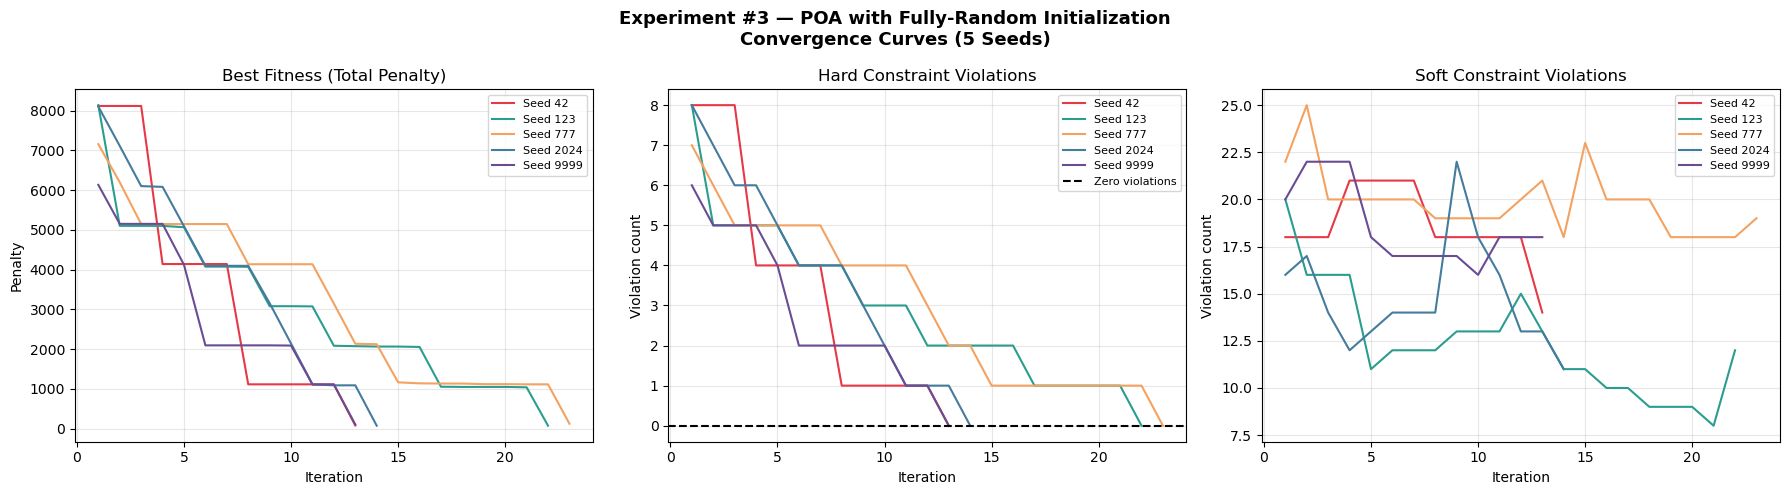


Convergence plot saved → poa_convergence_exp3.png

RESULTS SUMMARY TABLE
 seed  best_fitness  hard_viol  soft_viol  n_iterations  runtime_s  solved
   42          80.0          0         14            13       0.42    True
  123          75.0          0         12            22       0.58    True
  777         125.0          0         19            23       0.68    True
 2024          75.0          0         11            14       0.38    True
 9999         105.0          0         18            13       0.36    True

Mean fitness    : 92
Std  fitness    : 22
Mean hard viol  : 0.00
Solutions found : 5 / 5
Mean runtime    : 0.48 s

Best timetable exported → best_timetable_exp3.csv
  (seed=123, hard=0, soft=12)


In [19]:
# ──────────────────────────────────────────────────────────────
# Cell 13 ▸ Run the POA Algorithm — Experiment #3
#
# Three sub-experiments:
#   A. Scheduling order: Teachers → Rooms → Timeslots
#   B. Scheduling order: Rooms → Teachers → Timeslots
#   C. Scheduling order: Timeslots → Rooms → Teachers
#   + Main run with standard random init
# ──────────────────────────────────────────────────────────────

# ── Main POA run (Experiment #3 baseline) ─────────────────────
print("=" * 60)
print("EXPERIMENT #3 — POA with Fully-Random Initialization")
print("=" * 60)

POA_CONFIG = dict(
    n_pop         = 30,
    max_iter      = 300,
    stalk_base    = 0.40,
    attack_prob   = 0.50,
    levy_beta     = 1.5,
    stagnation_t1 = 15,
    stagnation_t2 = 30,
    stagnation_t3 = 50,
    verbose       = True,
)

print("\n>>> MAIN RUN (seed=42)  ...")
result = run_poa(**POA_CONFIG, seed=42)

# ── Decode & display best schedule ───────────────────────────
best_assignments = decode_solution(result["best_vec"])
df_best = pd.DataFrame(best_assignments)

print("\n" + "=" * 60)
print("BEST SCHEDULE — SUMMARY")
print("=" * 60)
print(f"Total units scheduled : {len(df_best)}")
print(f"Hard violations       : {result['best_hard']}")
print(f"Soft violations       : {result['best_soft']}")
print(f"Total penalty         : {result['best_fitness']:,.0f}")
print(f"Runtime               : {result['elapsed_s']:.2f} s")

print("\nSchedule sample (first 15 units):")
print(
    df_best[["unit_id","teacher_id","room_id","day","start_slot","end_slot","session_type"]]
    .head(15).to_string(index=False)
)

# Final detailed fitness breakdown
_, nh, ns, det = evaluate_fitness(result["best_vec"])
print("\nConstraint breakdown (best solution):")
for k, v in det.items():
    wname = "W_" + k[:2]
    w     = {"W_H1":W_H1,"W_H2":W_H2,"W_H3":W_H3,"W_H4":W_H4,"W_S1":W_S1,"W_S2":W_S2}[wname]
    status = "✓" if v == 0 else "✗"
    print(f"  {status} {k:28s}: {v:5d}  (×{w:5d} = {v*w:8,.0f})")

# ── Multi-seed robustness test ────────────────────────────────
print("\n" + "=" * 60)
print("ROBUSTNESS TEST — 5 independent runs (different seeds)")
print("=" * 60)

seeds   = [42, 123, 777, 2024, 9999]
results = []
for s in seeds:
    print(f"\n>>> Seed {s} ...")
    r = run_poa(**{**POA_CONFIG, "verbose": False}, seed=s)
    results.append(r)
    print(f"    fitness={r['best_fitness']:,.0f}  hard={r['best_hard']}  "
          f"soft={r['best_soft']}  iters={r['n_iterations']}  "
          f"time={r['elapsed_s']:.1f}s")

# ── Convergence plot ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Experiment #3 — POA with Fully-Random Initialization\n"
             "Convergence Curves (5 Seeds)", fontsize=13, fontweight="bold")

colors = ["#e63946","#2a9d8f","#f4a261","#457b9d","#6a4c93"]
seed_labels = [f"Seed {s}" for s in seeds]

# Panel 1: Best fitness
for r, color, label in zip(results, colors, seed_labels):
    iters = [h["iteration"] for h in r["history"]]
    fits  = [h["best_fitness"] for h in r["history"]]
    axes[0].plot(iters, fits, color=color, lw=1.5, label=label)
axes[0].set_title("Best Fitness (Total Penalty)")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Penalty")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Panel 2: Hard violations
for r, color, label in zip(results, colors, seed_labels):
    iters = [h["iteration"] for h in r["history"]]
    hard  = [h["best_hard"] for h in r["history"]]
    axes[1].plot(iters, hard, color=color, lw=1.5, label=label)
axes[1].axhline(0, color="black", lw=1.5, ls="--", label="Zero violations")
axes[1].set_title("Hard Constraint Violations")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Violation count")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# Panel 3: Soft violations
for r, color, label in zip(results, colors, seed_labels):
    iters = [h["iteration"] for h in r["history"]]
    soft  = [h["best_soft"] for h in r["history"]]
    axes[2].plot(iters, soft, color=color, lw=1.5, label=label)
axes[2].set_title("Soft Constraint Violations")
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("Violation count")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("poa_convergence_exp3.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nConvergence plot saved → poa_convergence_exp3.png")

# ── Results summary table ─────────────────────────────────────
df_results = pd.DataFrame([{
    "seed"         : r["seed"],
    "best_fitness" : r["best_fitness"],
    "hard_viol"    : r["best_hard"],
    "soft_viol"    : r["best_soft"],
    "n_iterations" : r["n_iterations"],
    "runtime_s"    : round(r["elapsed_s"], 2),
    "solved"       : r["best_hard"] == 0,
} for r in results])

print("\n" + "=" * 60)
print("RESULTS SUMMARY TABLE")
print("=" * 60)
print(df_results.to_string(index=False))
print(f"\nMean fitness    : {df_results['best_fitness'].mean():,.0f}")
print(f"Std  fitness    : {df_results['best_fitness'].std():,.0f}")
print(f"Mean hard viol  : {df_results['hard_viol'].mean():.2f}")
print(f"Solutions found : {df_results['solved'].sum()} / {len(df_results)}")
print(f"Mean runtime    : {df_results['runtime_s'].mean():.2f} s")

# ── Export best timetable to CSV ──────────────────────────────
# Use the best result across all seeds
best_result = min(results, key=lambda r: (r["best_hard"], r["best_fitness"]))
best_schedule = pd.DataFrame(decode_solution(best_result["best_vec"]))
best_schedule.to_csv("best_timetable_exp3.csv", index=False)
print("\nBest timetable exported → best_timetable_exp3.csv")
print(f"  (seed={best_result['seed']}, hard={best_result['best_hard']}, "
      f"soft={best_result['best_soft']})")
